<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/Peer_Visual_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip


In [2]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]
extract_path = "/content/underwater_data"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/underwater_data


In [3]:
!apt-get -qq update
!apt-get -qq install -y p7zip-full

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [4]:
import glob
import os

seven_zip_files = glob.glob(
    "/content/underwater_data/**/*.7z",
    recursive=True
)

print("7z files found:", len(seven_zip_files))

for f in seven_zip_files:
    output_dir = os.path.splitext(f)[0]
    os.makedirs(output_dir, exist_ok=True)

    !7z x "{f}" -o"{output_dir}" -y > /dev/null

print("All 7z files extracted.")

7z files found: 8
All 7z files extracted.


In [5]:
import glob
import os

image_files = []

for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    image_files.extend(
        glob.glob("/content/underwater_data/**/*.{}".format(
            ext.split(".")[-1]), recursive=True)
    )

image_files = sorted(set(image_files))

print("Total images found:", len(image_files))

Total images found: 3694


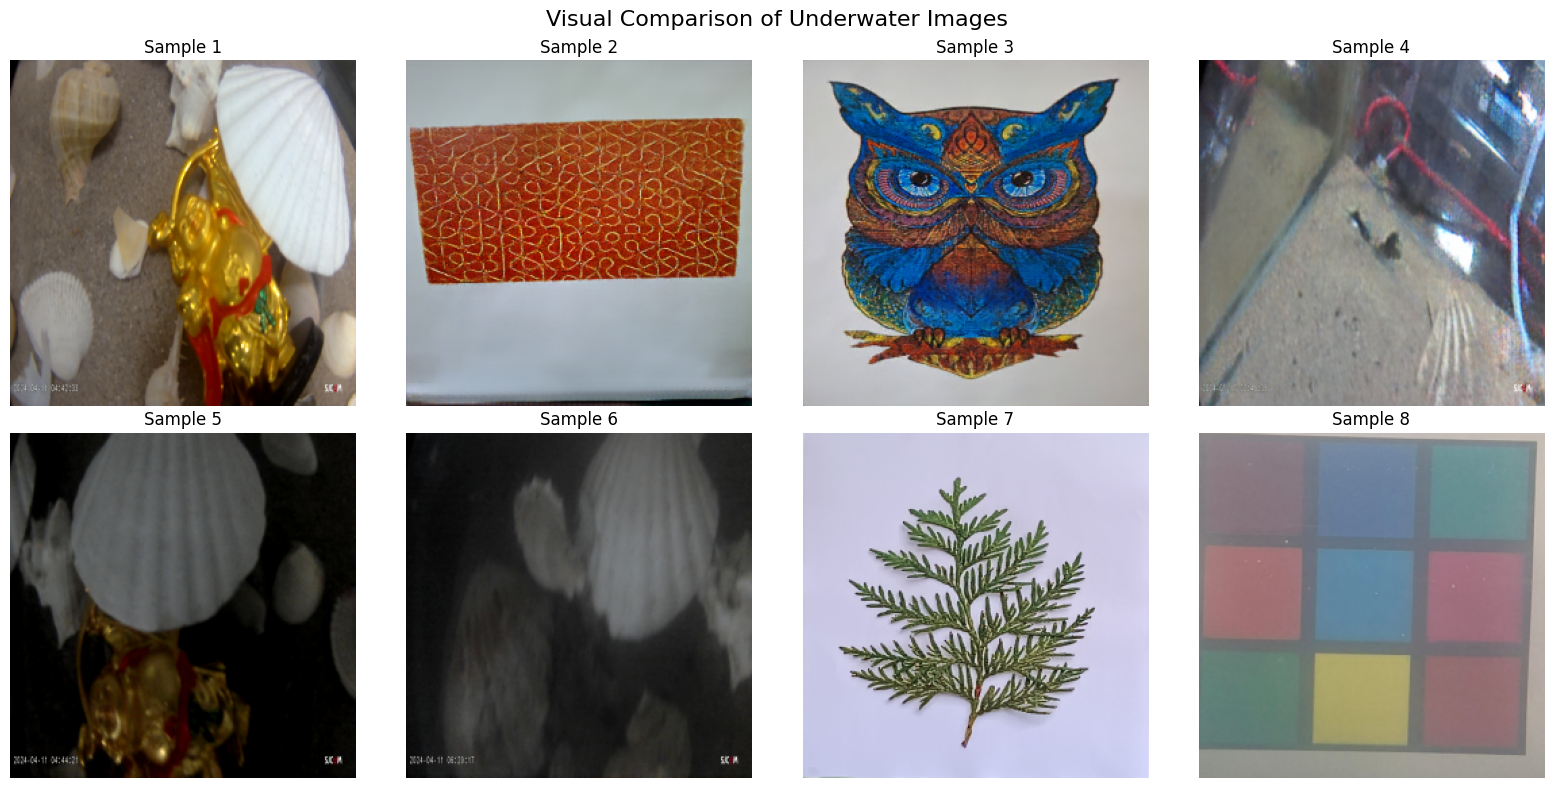

In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import random

random.seed(42)

sample_size = min(8, len(image_files))
sample_images = random.sample(image_files, sample_size)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path).convert("RGB")

    axes[i].imshow(img)
    axes[i].set_title(f"Sample {i+1}")
    axes[i].axis("off")

for i in range(sample_size, len(axes)):
    axes[i].axis("off")

plt.suptitle(
    "Visual Comparison of Underwater Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 1. Data and Sequence Findings

The dataset is primarily image-based. The available files were examined to understand
image quality, visual characteristics and possible relationships between samples.

The images show variations in:

- Brightness
- Contrast
- Color balance
- Green/blue color cast
- Underwater haze
- Visibility
- Sharpness
- Illumination

These variations indicate that the dataset contains different levels of underwater
image degradation.

Sequence interpretation should be handled carefully. Consecutive filenames or files
should not automatically be treated as temporal sequences unless the dataset structure
or documentation confirms that they belong to the same sequence.

Therefore, the current comparison focuses mainly on image-level characteristics rather
than assuming an unverified temporal relationship.

## 2. Data Leakage Analysis

Data leakage can occur when information from the validation or test data becomes
available during training.

Possible leakage risks include:

1. The same image appearing in multiple dataset splits.
2. Highly similar images being distributed across training and testing.
3. Augmented versions of test images being included in training.
4. Creating overlapping sequences before performing train/validation/test splitting.
5. Using test-set information while selecting preprocessing parameters.

### Leakage Prevention

To reduce leakage:

- Split the original data before creating sequences or windows.
- Keep training, validation and test images independent.
- Apply augmentation only to the training set.
- Do not augment the test set.
- Do not use test results to tune the model.
- If sequence/source information is available, split by source or sequence.

These precautions help ensure that the final evaluation represents the model's
performance on unseen data.

## 3. Degradation-Stage Analysis

Underwater images can be broadly considered at different degradation levels.

### Mild degradation
- Good visibility
- Moderate color distortion
- Reasonable brightness
- Limited haze

### Moderate degradation
- Noticeable color cast
- Reduced contrast
- Increased haze
- Lower visibility

### Severe degradation
- Strong green/blue color cast
- Very low visibility
- Strong haze
- Poor contrast
- Significant loss of image details

The degradation level can affect enhancement difficulty. Images with severe color
distortion, haze and low visibility are expected to be more difficult to restore.

## . Research Hypothesis

### Hypothesis

Images with stronger color distortion, heavier underwater haze, lower brightness
and reduced visibility will be more difficult for the enhancement model to restore
than images with mild degradation.

### Reason

Severe degradation can remove or distort important visual information, making it
harder for an enhancement model to recover natural colors, contrast and details.